# Drude Model for Silver Nanoparticles — `drude_model.py`

Three levels of approximation for the optical permittivity of a metallic nanoparticle:

| Model | Function | What is included |
|---|---|---|
| **Bulk Drude** | `eps_drude_bulk` | Bulk $\omega_p$, $\gamma_0$ — size-independent |
| **Nordlander** | `eps_drude_nano_nordlander` | + surface-scattering damping $\propto 1/R$ |
| **Quantum PWA** | `Sij` + `eps_PWA` | + discrete quantum-well dipole transitions $S_{ij}$ |

---

## Physical picture

In a **bulk metal** the conduction electrons are damped by electron-phonon and
electron-electron scattering at a rate $\gamma_0$.

In a **small nanoparticle** ($D \lesssim 20$ nm) electrons scatter off the surface
before completing a bulk-equivalent path, adding a size-dependent contribution:
$$\gamma_{\rm eff}(R) = \gamma_0 + \frac{\hbar v_F}{R}$$

In a **quantum nanoparticle** ($D \lesssim 10$ nm) the continuous conduction band
splits into discrete spherical quantum-well levels $(n, \ell)$.
Optical absorption can only occur at the discrete transition energies $\Omega_{ij}$,
captured by the Garcia de Abajo PWA oscillator strengths $S_{ij}$.


## Step 0 - Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import plytrons.quantum_well as qw
from plytrons.drude_model import (
    eps_drude_bulk,
    eps_drude_nano_nordlander,
    Sij,
    eps_PWA,
)

hbar_eVs = 6.582119569e-16   # hbar in eV*s  (for Nordlander formula)


---
## Step 1 - Bulk Drude model

The Drude permittivity for bulk silver:

$$\varepsilon(\omega) = \varepsilon_b - \frac{\omega_p^2}{\omega(\omega + i\gamma_0)}$$

Silver parameters:

| Parameter | Value |
|---|---|
| $\varepsilon_b$ | 4.18 (background from interband transitions) |
| $\hbar\omega_p$ | 9.07 eV (plasma frequency) |
| $\hbar\gamma_0$ | 0.06 eV (bulk scattering rate) |

The quasi-static plasmon condition $\mathrm{Re}[\varepsilon] = -2\varepsilon_h$
gives the Frohlich frequency $\omega_F = \omega_p / \sqrt{\varepsilon_b + 2}$.


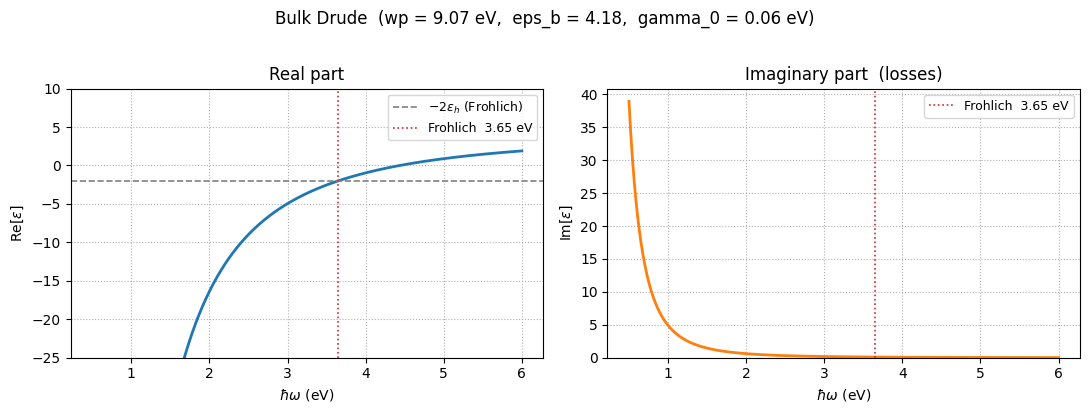

Frohlich frequency:  hbar*omega_F = 3.648 eV
  = wp / sqrt(eps_b + 2) = 9.07 / sqrt(6.18) = 3.648 eV


In [10]:
# -- Silver bulk parameters ----------------------------------------
wp_eV  = 9.07    # plasma frequency [eV]
eps_b  = 4.18    # background permittivity
gamma0 = 0.06    # bulk damping [eV]
vf     = 1.39e6  # Fermi velocity [m/s]
EF     = 5.5     # Fermi energy [eV]

omega_eV = np.linspace(0.5, 6.0, 1000)

eps_bulk = eps_drude_bulk(omega_eV, wp_eV=wp_eV, eps_b=eps_b, gamma0=gamma0)

# Frohlich frequency: Re[eps(omega_F)] = -2  =>  omega_F = wp/sqrt(eps_b+2)
omega_F = wp_eV / np.sqrt(eps_b + 2.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(omega_eV, eps_bulk.real, 'C0', lw=2)
ax.axhline(-2, ls='--', lw=1.2, color='gray', label=r'$-2\varepsilon_h$ (Frohlich)')
ax.axvline(omega_F, ls=':', lw=1.2, color='C3', label=f'Frohlich  {omega_F:.2f} eV')
ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Re}[\varepsilon]$')
ax.set_title('Real part')
ax.set_ylim(-25, 10)
ax.legend(fontsize=9)
ax.grid(True, ls=':')

ax = axes[1]
ax.plot(omega_eV, eps_bulk.imag, 'C1', lw=2)
ax.axvline(omega_F, ls=':', lw=1.2, color='C3', label=f'Frohlich  {omega_F:.2f} eV')
ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Im}[\varepsilon]$')
ax.set_title('Imaginary part  (losses)')
ax.set_ylim(0, None)
ax.legend(fontsize=9)
ax.grid(True, ls=':')

fig.suptitle(
    f'Bulk Drude  (wp = {wp_eV} eV,  eps_b = {eps_b},  gamma_0 = {gamma0} eV)',
    y=1.02)
plt.tight_layout()
plt.show()

print(f'Frohlich frequency:  hbar*omega_F = {omega_F:.3f} eV')
print(f'  = wp / sqrt(eps_b + 2) = {wp_eV:.2f} / sqrt({eps_b+2:.2f}) = {omega_F:.3f} eV')


---
## Step 2 - Size-corrected Drude (Nordlander)

For a nanoparticle of radius $R$, electrons scatter off the surface at a rate:

$$\gamma_{\rm surf}(R) = \frac{\hbar v_F}{R}$$

The effective damping becomes:

$$\gamma_{\rm eff}(R) = \gamma_0 + \frac{\hbar v_F}{R}$$

This is inserted into the Drude formula, keeping the same functional form
but with a size-dependent imaginary part.

Key consequence: the plasmon peak **broadens** as $D$ decreases, and the
absorption cross-section per volume decreases relative to the bulk prediction.


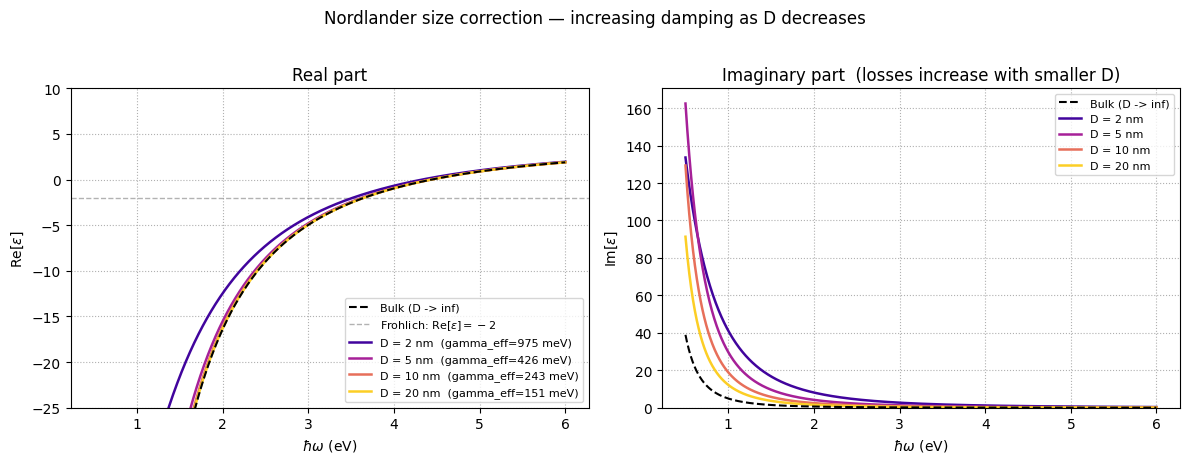

In [11]:
D_list = [2, 5, 10, 20]
colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(D_list)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# -- Real part
ax = axes[0]
ax.plot(omega_eV, eps_bulk.real, 'k--', lw=1.5, label='Bulk (D -> inf)', zorder=5)
ax.axhline(-2, ls='--', lw=1, color='gray', alpha=0.6, label=r'Frohlich: $\mathrm{Re}[\varepsilon]=-2$')

for D, col in zip(D_list, colors):
    eps_n = eps_drude_nano_nordlander(omega_eV, D_nm=D, wp_eV=wp_eV,
                                       eps_b=eps_b, gamma0=gamma0, vf=vf)
    R_m   = (D / 2) * 1e-9
    g_eff = gamma0 + hbar_eVs * vf / R_m
    ax.plot(omega_eV, eps_n.real, color=col, lw=1.8,
            label=f'D = {D} nm  (gamma_eff={g_eff*1e3:.0f} meV)')

ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Re}[\varepsilon]$')
ax.set_title('Real part')
ax.set_ylim(-25, 10)
ax.legend(fontsize=8)
ax.grid(True, ls=':')

# -- Imaginary part
ax = axes[1]
ax.plot(omega_eV, eps_bulk.imag, 'k--', lw=1.5, label='Bulk (D -> inf)', zorder=5)

for D, col in zip(D_list, colors):
    eps_n = eps_drude_nano_nordlander(omega_eV, D_nm=D, wp_eV=wp_eV,
                                       eps_b=eps_b, gamma0=gamma0, vf=vf)
    ax.plot(omega_eV, eps_n.imag, color=col, lw=1.8, label=f'D = {D} nm')

ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Im}[\varepsilon]$')
ax.set_title('Imaginary part  (losses increase with smaller D)')
ax.set_ylim(0, None)
ax.legend(fontsize=8)
ax.grid(True, ls=':')

fig.suptitle('Nordlander size correction — increasing damping as D decreases', y=1.02)
plt.tight_layout()
plt.show()


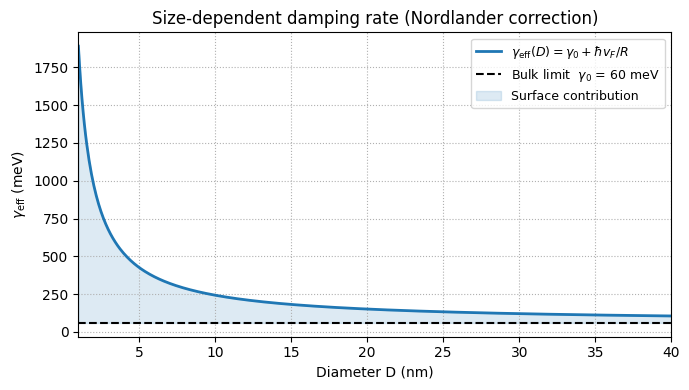

Effective damping at selected sizes:
  D =    2 nm:  gamma_eff =  974.9 meV  (16.2x bulk)
  D =    5 nm:  gamma_eff =  426.0 meV  (7.1x bulk)
  D =   10 nm:  gamma_eff =  243.0 meV  (4.0x bulk)
  D =   20 nm:  gamma_eff =  151.5 meV  (2.5x bulk)


In [12]:
# -- gamma_eff(D) -------------------------------------------------------
D_range = np.linspace(1, 40, 500)
R_range = (D_range / 2) * 1e-9   # m

g_surf_range = hbar_eVs * vf / R_range   # eV
g_eff_range  = gamma0 + g_surf_range

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(D_range, g_eff_range * 1e3, 'C0', lw=2,
        label=r'$\gamma_{\rm eff}(D) = \gamma_0 + \hbar v_F / R$')
ax.axhline(gamma0 * 1e3, ls='--', lw=1.5, color='k',
           label=f'Bulk limit  $\gamma_0$ = {gamma0*1e3:.0f} meV')
ax.fill_between(D_range, gamma0 * 1e3, g_eff_range * 1e3,
                alpha=0.15, color='C0', label='Surface contribution')

ax.set_xlabel('Diameter D (nm)')
ax.set_ylabel(r'$\gamma_{\rm eff}$ (meV)')
ax.set_title('Size-dependent damping rate (Nordlander correction)')
ax.set_xlim(1, 40)
ax.legend(fontsize=9)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

print('Effective damping at selected sizes:')
for D in [2, 5, 10, 20]:
    R_m = (D / 2) * 1e-9
    g   = gamma0 + hbar_eVs * vf / R_m
    print(f'  D = {D:>4} nm:  gamma_eff = {g*1e3:6.1f} meV  ({g/gamma0:.1f}x bulk)')


---
## Step 3 - Quantum-well bound states

In a small metallic sphere, the conduction electrons are confined to a
**spherical quantum well** of radius $a = D/2$.
The eigenstates are labelled $(n, \ell)$ where $\ell$ is the angular momentum
and $n$ counts radial nodes.
Their wavefunctions are spherical Bessel functions $j_\ell(k_{n\ell} r)$ inside the sphere.

These discrete levels replace the continuous conduction band and are the
input to the quantum PWA permittivity.


D = 5.0 nm  (a = 2.5 nm)
Quantum-well levels:  lmax = 42,  total (n,l) states = 296
Fermi energy: EF = 5.5 eV


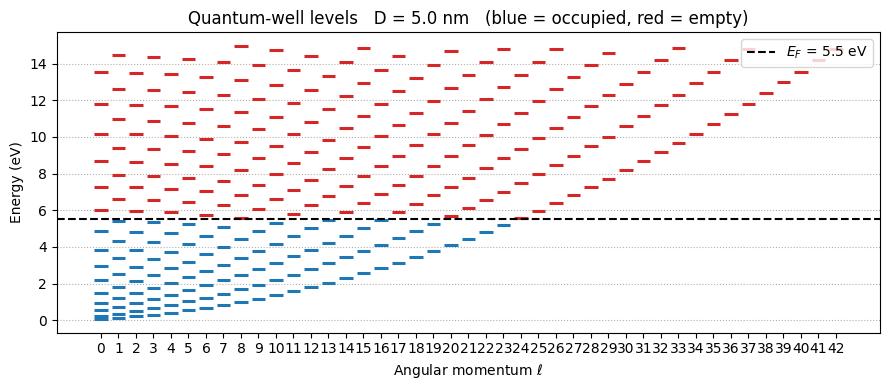

In [13]:
D_nm = 5.0     # nanoparticle diameter [nm] for the quantum comparison
a_nm = D_nm / 2.0

E_matrix = qw.get_bound_states(a_nm)
A_matrix = qw.get_normalization(a_nm, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

lmax_qw = len(e_states)
N_total  = sum(e_states[l].Eb.size for l in range(lmax_qw))
print(f'D = {D_nm} nm  (a = {a_nm} nm)')
print(f'Quantum-well levels:  lmax = {lmax_qw - 1},  total (n,l) states = {N_total}')
print(f'Fermi energy: EF = {EF} eV')

# -- Level diagram ---------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))

for l in range(lmax_qw):
    for E in e_states[l].Eb.real:
        Ef  = float(E)
        col = 'C0' if Ef < EF else 'C3'
        ax.hlines(Ef, l - 0.38, l + 0.38, colors=col, lw=2.2)

ax.axhline(EF, ls='--', lw=1.5, color='k', label=f'$E_F$ = {EF} eV')
ax.set_xlabel('Angular momentum $\ell$')
ax.set_ylabel('Energy (eV)')
ax.set_title(f'Quantum-well levels   D = {D_nm} nm   (blue = occupied, red = empty)')
ax.set_xticks(range(lmax_qw))
ax.legend()
ax.grid(True, ls=':', axis='y')
plt.tight_layout()
plt.show()


---
## Step 4 - PWA oscillator strengths $S_{ij}$

The Garcia de Abajo plane-wave approximation describes the optical response
as a sum over discrete quantum transitions:

$$S_{ij} = \frac{2 m_e}{\hbar^2 N_e}(E_f - E_i)(f_i - f_f)|\langle f|z|i \rangle|^2$$

where $|\langle f|z|i \rangle|^2$ is the electric dipole matrix element between
quantum-well states $(n_i, \ell_i)$ and $(n_f, \ell_f)$.

Selection rules (for $z$-polarisation):
- $\Delta\ell = \pm 1$
- $\Delta m = 0$

**$f$-sum rule:** $\displaystyle\sum_{ij} S_{ij} = 1$ (total oscillator strength is conserved)

Each $S_{ij}$ contributes a Lorentzian pole at $\omega = \Omega_{ij}$ to the permittivity.


Computing Sij for D = 5.0 nm ...
(First call JIT-compiles the Numba kernel — may take ~10-20 s)
Done.
Ne = 3837.0 conduction electrons in sphere
Number of transitions: 2324
f-sum rule:  Sum S_ij = 0.4409  (should be 1.0)



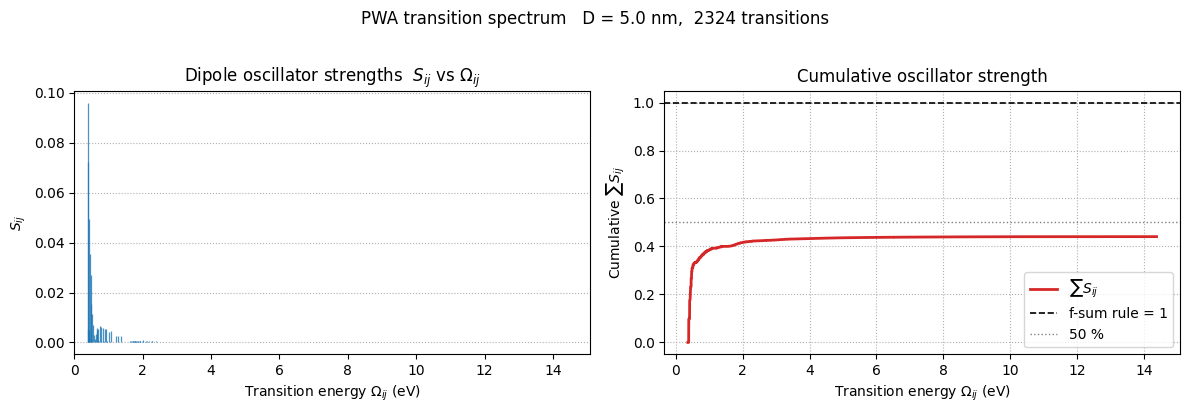

In [14]:
print(f'Computing Sij for D = {D_nm} nm ...')
print('(First call JIT-compiles the Numba kernel — may take ~10-20 s)')
wij_vals, Sij_vals, Ne = Sij(a_nm=a_nm, E_F=EF, e_state=e_states)
print(f'Done.')
print(f'Ne = {Ne:.1f} conduction electrons in sphere')
print(f'Number of transitions: {len(wij_vals)}')
print(f'f-sum rule:  Sum S_ij = {Sij_vals.sum():.4f}  (should be 1.0)')
print()

# Sort by transition energy for display
isort  = np.argsort(wij_vals)
wij_s  = wij_vals[isort]
Sij_s  = Sij_vals[isort]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.vlines(wij_s, 0, Sij_s, colors='C0', lw=0.9, alpha=0.8)
ax.set_xlabel(r'Transition energy $\Omega_{ij}$ (eV)')
ax.set_ylabel(r'$S_{ij}$')
ax.set_title(r'Dipole oscillator strengths  $S_{ij}$ vs $\Omega_{ij}$')
ax.set_xlim(0, None)
ax.grid(True, ls=':', axis='y')

ax = axes[1]
ax.plot(wij_s, np.cumsum(Sij_s), 'C3', lw=2, label=r'$\sum S_{ij}$')
ax.axhline(1.0, ls='--', lw=1.2, color='k', label='f-sum rule = 1')
ax.axhline(0.5, ls=':', lw=1, color='gray', label='50 %')
ax.set_xlabel(r'Transition energy $\Omega_{ij}$ (eV)')
ax.set_ylabel(r'Cumulative $\sum S_{ij}$')
ax.set_title('Cumulative oscillator strength')
ax.legend()
ax.grid(True, ls=':')

fig.suptitle(f'PWA transition spectrum   D = {D_nm} nm,  {len(wij_vals)} transitions',
             y=1.02)
plt.tight_layout()
plt.show()


---
## Step 5 - Permittivity comparison: Bulk vs Nordlander vs PWA

The PWA permittivity replaces the single Drude pole with a sum over quantum transitions:

$$\varepsilon_{\rm PWA}(\omega) = \varepsilon_b + \omega_p^2 \sum_{ij}
\frac{2 S_{ij}}{\Omega_{ij}^2 - \omega(\omega + i\gamma)}$$

In the limit of a dense, continuous spectrum this recovers the Drude result.
For small nanoparticles the discrete $S_{ij}$ spectrum causes:

1. **Fine structure** in $\mathrm{Im}[\varepsilon]$ at each $\Omega_{ij}$
2. **Modified peak position** relative to the classical models
3. **Non-classical broadening** that depends on the density of transitions near the plasmon energy


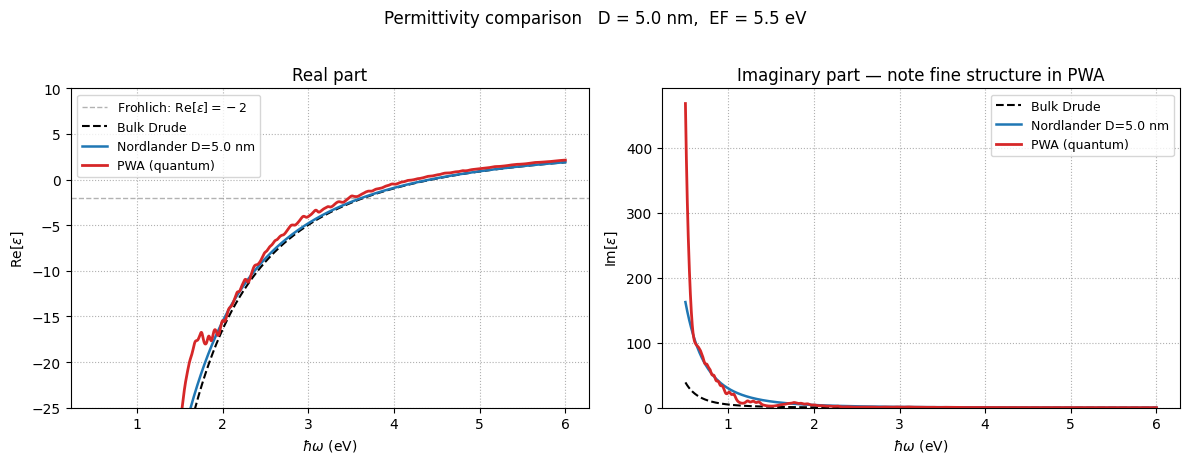

In [15]:
omega_cmp = np.linspace(0.5, 6.0, 2000)

eps_b_arr = eps_drude_bulk(omega_cmp, wp_eV=wp_eV, eps_b=eps_b, gamma0=gamma0)
eps_n_arr = eps_drude_nano_nordlander(omega_cmp, D_nm=D_nm, wp_eV=wp_eV,
                                       eps_b=eps_b, gamma0=gamma0, vf=vf)
eps_pwa   = eps_PWA(wij_vals, Sij_vals, omega_cmp,
                    wp_eV=wp_eV, eps_b=eps_b, gamma_eV=gamma0, show_progress=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

models = [
    (eps_b_arr, 'Bulk Drude',              'k',  '--', 1.5),
    (eps_n_arr, f'Nordlander D={D_nm} nm', 'C0', '-',  1.8),
    (eps_pwa,   'PWA (quantum)',            'C3', '-',  2.0),
]

ax = axes[0]
ax.axhline(-2, ls='--', lw=1, color='gray', alpha=0.6,
           label=r'Frohlich: $\mathrm{Re}[\varepsilon]=-2$')
for eps, label, col, ls, lw in models:
    ax.plot(omega_cmp, eps.real, color=col, ls=ls, lw=lw, label=label)
ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Re}[\varepsilon]$')
ax.set_title('Real part')
ax.set_ylim(-25, 10)
ax.legend(fontsize=9)
ax.grid(True, ls=':')

ax = axes[1]
for eps, label, col, ls, lw in models:
    ax.plot(omega_cmp, eps.imag, color=col, ls=ls, lw=lw, label=label)
ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$\mathrm{Im}[\varepsilon]$')
ax.set_title('Imaginary part — note fine structure in PWA')
ax.set_ylim(0, None)
ax.legend(fontsize=9)
ax.grid(True, ls=':')

fig.suptitle(f'Permittivity comparison   D = {D_nm} nm,  EF = {EF} eV', y=1.02)
plt.tight_layout()
plt.show()


---
## Step 6 - Absorption efficiency: quasi-static approximation

In the quasi-static (Rayleigh) limit $2\pi a / \lambda \ll 1$, the dipole
polarisability is:

$$\alpha(\omega) = a^3 \frac{\varepsilon(\omega) - \varepsilon_h}{\varepsilon(\omega) + 2\varepsilon_h}$$

and the absorption efficiency scales as:

$$Q_{\rm abs}(\omega) \propto \omega \,\mathrm{Im}[\alpha / a^3]
= \omega \,\mathrm{Im}\!\left[\frac{\varepsilon - 1}{\varepsilon + 2}\right]$$

The denominator $|\varepsilon + 2|^2$ is minimised at the Frohlich condition,
producing the absorption peak.
Comparing the three models reveals how surface scattering and quantum discretisation
affect the **peak position** and **linewidth**.


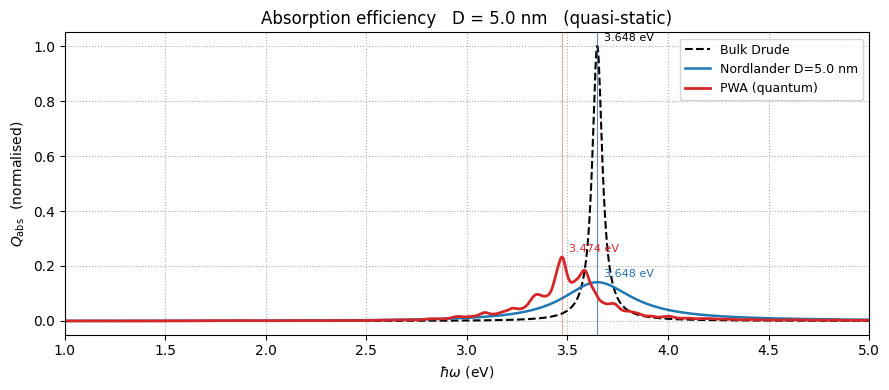

In [16]:
def quasi_static_Qabs(eps, omega_eV, eps_h=1.0):
    """Q_abs proportional to omega * Im[(eps - eps_h)/(eps + 2*eps_h)]."""
    return omega_eV * ((eps - eps_h) / (eps + 2 * eps_h)).imag

Qabs_bulk = quasi_static_Qabs(eps_b_arr, omega_cmp)
Qabs_nord = quasi_static_Qabs(eps_n_arr, omega_cmp)
Qabs_pwa  = quasi_static_Qabs(eps_pwa,   omega_cmp)

norm = max(Qabs_bulk.max(), Qabs_nord.max(), Qabs_pwa.max())

fig, ax = plt.subplots(figsize=(9, 4))

for Qabs, label, col, ls, lw in [
        (Qabs_bulk, 'Bulk Drude',              'k',  '--', 1.5),
        (Qabs_nord, f'Nordlander D={D_nm} nm', 'C0', '-',  1.8),
        (Qabs_pwa,  'PWA (quantum)',            'C3', '-',  2.0),
    ]:
    ax.plot(omega_cmp, Qabs / norm, color=col, ls=ls, lw=lw, label=label)

    pks, _ = find_peaks(Qabs, height=0.05 * Qabs.max())
    if len(pks):
        pk = pks[np.argmax(Qabs[pks])]
        ax.axvline(omega_cmp[pk], lw=0.8, color=col, alpha=0.4)
        ax.annotate(f'{omega_cmp[pk]:.3f} eV',
                    xy=(omega_cmp[pk], Qabs[pk] / norm),
                    xytext=(5, 4), textcoords='offset points',
                    fontsize=8, color=col)

ax.set_xlabel(r'$\hbar\omega$ (eV)')
ax.set_ylabel(r'$Q_{\rm abs}$  (normalised)')
ax.set_title(f'Absorption efficiency   D = {D_nm} nm   (quasi-static)')
ax.legend(fontsize=9)
ax.grid(True, ls=':')
ax.set_xlim(1.0, 5.0)
plt.tight_layout()
plt.show()


---
## Step 7 - Size dependence of the plasmon resonance

We sweep the nanoparticle diameter and track:

- **Peak position** $\hbar\omega_{\rm res}(D)$
- **Linewidth** FWHM(D)

for the Bulk and Nordlander models (fast, no quantum calculation).

A few selected sizes include the PWA prediction to show when quantum
discretisation becomes significant.


D = 2 nm:  PWA peak = 3.299 eV,  FWHM = 60 meV
D = 5 nm:  PWA peak = 3.473 eV,  FWHM = 205 meV
D = 8 nm:  PWA peak = 3.533 eV,  FWHM = 191 meV
D = 10 nm:  PWA peak = 3.577 eV,  FWHM = 174 meV
D = 12 nm:  PWA peak = 3.575 eV,  FWHM = 156 meV
D = 15 nm:  PWA peak = 3.593 eV,  FWHM = 130 meV
D = 18 nm:  PWA peak = 3.601 eV,  FWHM = 119 meV
D = 20 nm:  PWA peak = 3.605 eV,  FWHM = 113 meV


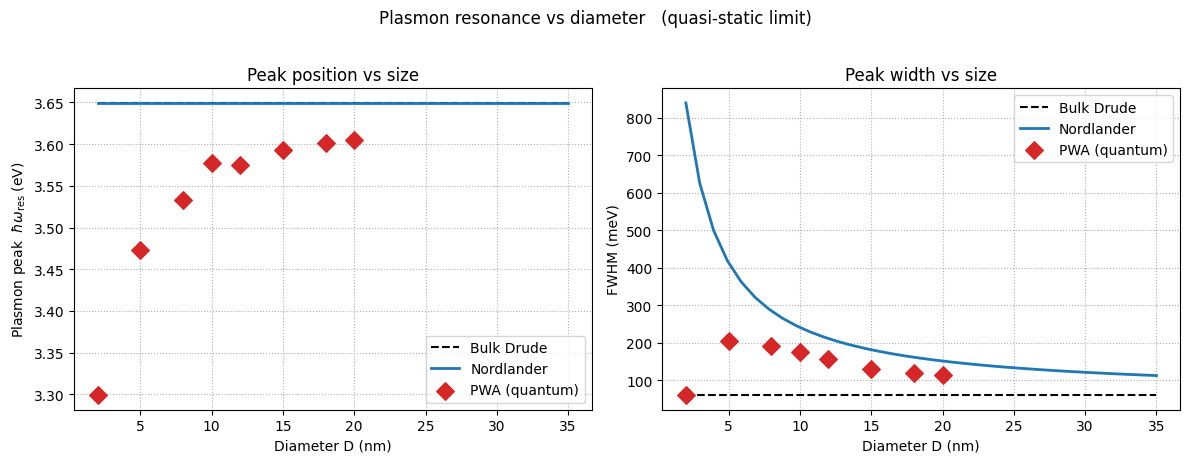

In [18]:
D_sweep  = np.linspace(2, 35, 35)
omega_sw = np.linspace(1.0, 5.0, 2000)
dw       = omega_sw[1] - omega_sw[0]

peak_bulk, width_bulk = [], []
peak_nord, width_nord = [], []

for D in D_sweep:
    for which, pl, wl in [('bulk', peak_bulk, width_bulk),
                           ('nord', peak_nord, width_nord)]:
        if which == 'bulk':
            eps = eps_drude_bulk(omega_sw, wp_eV=wp_eV, eps_b=eps_b, gamma0=gamma0)
        else:
            eps = eps_drude_nano_nordlander(omega_sw, D_nm=D, wp_eV=wp_eV,
                                             eps_b=eps_b, gamma0=gamma0, vf=vf)
        Qabs = omega_sw * ((eps - 1) / (eps + 2)).imag
        pks, props = find_peaks(Qabs, height=0.01 * Qabs.max(), width=1)
        if len(pks):
            best = pks[np.argmax(Qabs[pks])]
            pl.append(omega_sw[best])
            wl.append(props['widths'][np.argmax(Qabs[pks])] * dw)
        else:
            pl.append(np.nan)
            wl.append(np.nan)

peak_bulk  = np.array(peak_bulk)
peak_nord  = np.array(peak_nord)
width_bulk = np.array(width_bulk)
width_nord = np.array(width_nord)

# -- PWA for three selected sizes (calls Sij again) --------------------
D_pwa    = [2, 5, 8, 10, 12, 15, 18, 20]
pk_pwa   = []
fwhm_pwa = []

for D_p in D_pwa:
    a_p = D_p / 2.0
    Em  = qw.get_bound_states(a_p)
    Am  = qw.get_normalization(a_p, Em)
    es  = qw.e_state_assembly(Em, Am)
    wp_, Sp_, _ = Sij(a_nm=a_p, E_F=EF, e_state=es)
    eps_p = eps_PWA(wp_, Sp_, omega_sw, wp_eV=wp_eV, eps_b=eps_b,
                    gamma_eV=gamma0, show_progress=False)
    Qabs_p = omega_sw * ((eps_p - 1) / (eps_p + 2)).imag
    pks_p, props_p = find_peaks(Qabs_p, height=0.01 * Qabs_p.max(), width=1)
    if len(pks_p):
        best = pks_p[np.argmax(Qabs_p[pks_p])]
        pk_pwa.append(omega_sw[best])
        fwhm_pwa.append(props_p['widths'][np.argmax(Qabs_p[pks_p])] * dw)
    else:
        pk_pwa.append(np.nan)
        fwhm_pwa.append(np.nan)
    print(f'D = {D_p} nm:  PWA peak = {pk_pwa[-1]:.3f} eV,  FWHM = {fwhm_pwa[-1]*1e3:.0f} meV')

# -- Plot --------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(D_sweep, peak_bulk, 'k--', lw=1.5, label='Bulk Drude')
ax.plot(D_sweep, peak_nord, 'C0-', lw=2,   label='Nordlander')
ax.scatter(D_pwa, pk_pwa, s=80, color='C3', zorder=5, marker='D', label='PWA (quantum)')
ax.set_xlabel('Diameter D (nm)')
ax.set_ylabel(r'Plasmon peak  $\hbar\omega_{\rm res}$ (eV)')
ax.set_title('Peak position vs size')
ax.legend()
ax.grid(True, ls=':')

ax = axes[1]
ax.plot(D_sweep, np.array(width_bulk) * 1e3, 'k--', lw=1.5, label='Bulk Drude')
ax.plot(D_sweep, np.array(width_nord) * 1e3, 'C0-', lw=2,   label='Nordlander')
ax.scatter(D_pwa, np.array(fwhm_pwa) * 1e3,  s=80, color='C3', zorder=5,
           marker='D', label='PWA (quantum)')
ax.set_xlabel('Diameter D (nm)')
ax.set_ylabel('FWHM (meV)')
ax.set_title('Peak width vs size')
ax.legend()
ax.grid(True, ls=':')

fig.suptitle('Plasmon resonance vs diameter   (quasi-static limit)', y=1.02)
plt.tight_layout()
plt.show()


---
## Summary

| Model | Function | When to use |
|---|---|---|
| **Bulk Drude** | `eps_drude_bulk` | $D > 30$ nm, quick estimate |
| **Nordlander** | `eps_drude_nano_nordlander` | $2 < D < 30$ nm, classical surface damping |
| **Quantum PWA** | `Sij` + `eps_PWA` | $D < 10$ nm, quantum discretisation important |

### Key physical messages

1. **Bulk Drude** — resonance position and width are size-independent. Useful as a baseline.

2. **Nordlander** — adds $\gamma_{\rm surf} = \hbar v_F / R$. The peak **broadens** strongly below
   $D \approx 10$ nm but the position barely shifts in the quasi-static limit.

3. **PWA** — discrete $S_{ij}$ transitions introduce fine structure in $\varepsilon(\omega)$.
   The main plasmon peak shifts and its shape is no longer a pure Lorentzian.
   At very small $D$ the quantum model is the only one with predictive power.

### Architecture

```
quantum_well.py  get_bound_states / e_state_assembly  -->  e_states (n, l levels)
                                                             |
drude_model.py   Sij(a_nm, EF, e_states)              -->  wij, Sij_vals   (transition spectrum)
                 eps_PWA(wij, Sij_vals, omega)         -->  eps_PWA(omega)  (quantum)
                 eps_drude_nano_nordlander(omega, D)   -->  eps_nano(omega) (semi-classical)
                 eps_drude_bulk(omega)                 -->  eps_bulk(omega) (classical)
```

The `Sij` kernel is JIT-compiled with Numba for speed; subsequent calls
(different sizes) reuse the compiled code.
